# 2. Valeurs zêta multiples finies — l'anneau des adèles du pauvre

*Distillation exécutable pour le centenaire de Jean-Pierre Serre (serre100.sciencesconf.org). Compagnon du notebook 01 de la série (corps finis et borne de Hasse, porté par une autre lane).*

La série harmonique généralisée $H^{(s)}_{p-1} = \sum_{k=1}^{p-1} 1/k^s$ vit dans les rationnels,
mais elle projette une **ombre** dans l'anneau fini $\mathbb{Z}/p^N\mathbb{Z}$ : on y remplace chaque
$1/k^s$ par l'inverse de $k^s$ modulo $p^N$. Kaneko et Zagier (2015) ont montré que ces ombres —
les **valeurs zêta multiples finies** $\zeta_p(m_1,\dots,m_r)$ — obéissent à une algèbre
analogue à celle des vraies valeurs zêta multiples $\zeta(m_1,\dots,m_r)$ : mêmes produits
(stuffle), mêmes relations de symétrie, et un double shuffle à condition de choisir la bonne
définition. D'où le titre : une seule famille de sommes, lue simultanément dans le régime réel
(archimédien) et dans le régime $p$-adique — « l'anneau des adèles du pauvre », où le pauvre
n'a besoin ni de topologie ni de convergence.

**Ce notebook mesure avant d'affirmer** : chaque identité de cette page est vérifiée
exactement (arithmétique entière, zéro flottant dans les congruences) sur une batterie de
nombres premiers, et les sorties commises sont la preuve. Les preuves complètes élémentaires
sont écrites en prose là où elles tiennent en trois lignes ; les théorèmes cités
(Wolstenholme, Leudesdorf, pont de Bernoulli, Kaneko–Zagier) sont mesurés, pas démontrés.

**Plan** :
1. **Profondeur 1, couche $p$** : l'ombre simple $\zeta_p(s)$ est *muette* — un argument de
   groupe cyclique l'explique, et toute l'information migre vers la couche $p^2$.
2. **Profondeur 1, couche $p^2$** : Wolstenholme, Leudesdorf, et le pont de Bernoulli
   $H^{(2)}_{p-1} \equiv \tfrac{2}{3}\,p\,B_{p-3} \pmod{p^2}$.
3. **Profondeur 2, couche $p$** : le produit stuffle exact, le retournement par involution,
   et la dérivée qu'ils engendrent : les poids *pairs* s'effacent, les poids *impairs*
   survivent — l'information migre en profondeur. Puis le test du transport naïf de la
   formule d'Euler : il échoue exactement là où l'information vit (mesuré).
4. **L'ombre réelle** : convergence $\sum 1/k^2 \to \pi^2/6$ d'un côté, oscillation
   bernoullienne du premier chiffre $p$-adique de l'autre ; le pont $\zeta_p(1,1)$.
5. **Trois exercices** (stuffle triple, retournement en profondeur 3, nombre premier de
   Wolstenholme).


In [1]:
# ============================================================
# Outils : arithmetique entiere exacte, stdlib pure.
# Toutes les congruences sont calculees sur des entiers (pow a modulo),
# aucun flottant n'entre dans une identite.
# ============================================================
from math import comb
from fractions import Fraction

def premiers(jusqua):
    """Crible d'Eratosthenes : nombres premiers <= jusqua."""
    crible = bytearray([1]) * (jusqua + 1)
    crible[0:2] = b'\x00\x00'
    for n in range(2, int(jusqua ** 0.5) + 1):
        if crible[n]:
            crible[n * n:: n] = bytearray(len(crible[n * n:: n]))
    return [n for n in range(2, jusqua + 1) if crible[n]]

def inv_mod(k, m):
    """Inverse de k modulo m (k premier a m)."""
    return pow(k, -1, m)

def zeta_p(p, s, N=1):
    """Ombre d'indice simple : H^(s)_{p-1} = somme des k^{-s}, calculee dans Z/p^N.
    pow(k, -1, m) est l'inverse modulaire ; on somme les puissances s-iemes de ces inverses."""
    m = p ** N
    return sum(pow(inv_mod(k, m), s, m) for k in range(1, p)) % m

def zeta_p2(p, m_, n_, N=1):
    """Ombre de profondeur 2 :
    zeta_p(m,n) = somme 1/(k1^m * k2^n) pour 0 < k2 < k1 < p, dans Z/p^N."""
    mod = p ** N
    return sum((pow(k1, -m_, mod) * pow(k2, -n_, mod)) % mod
               for k1 in range(2, p) for k2 in range(1, k1)) % mod

def bernoulli(n):
    """Liste B_0..B_{n-1} en rationnels exacts, recurrence standard
    sum(C(n+1,k) B_k) = 0 pour n >= 1, B_0 = 1."""
    B = [Fraction(1)]
    for n_ in range(1, n):
        acc = sum(comb(n_ + 1, k) * B[k] for k in range(n_))
        B.append(Fraction(-acc, n_ + 1))
    return B

def frac_mod(fr, m):
    """Image d'un rationnel (denominateur premier a m) dans Z/m."""
    return (fr.numerator * pow(fr.denominator, -1, m)) % m

PRIMES = premiers(100)
BER = bernoulli(90)
assert BER[1] == Fraction(-1, 2) and BER[2] == Fraction(1, 6) and BER[10] == Fraction(5, 66)

# Sanity check visible : H_4^(1) = 1 + 1/2 + 1/3 + 1/4 = 25/12,
# et 25 * inv(12) mod 5 = 0 : Wolstenholme a l'oeil nu sur p = 5.
print(f"Outils charges : {len(PRIMES)} premiers <= 100, Bernoulli exacts jusqu'a B_89.")
print(f"Verification : H_4 = 25/12 -> 25 * inv(12) mod 5 = {25 * inv_mod(12, 5) % 5}"
      f" (nul : 5^2 = 25 divise le numerateur, c'est Wolstenholme pour p = 5).")

Outils charges : 25 premiers <= 100, Bernoulli exacts jusqu'a B_89.
Verification : H_4 = 25/12 -> 25 * inv(12) mod 5 = 0 (nul : 5^2 = 25 divise le numerateur, c'est Wolstenholme pour p = 5).


## 1. Profondeur 1, couche $p$ : une ombre muette

Pour un premier $p$ et $s \geq 1$, l'ombre d'indice simple est

$$\zeta_p(s) \;=\; \sum_{k=1}^{p-1} \frac{1}{k^s} \;\in\; \mathbb{F}_p,$$

où $1/k^s$ se lit comme l'inverse modulaire. C'est $H^{(s)}_{p-1}$, la somme harmonique
généralisée d'ordre $s$ tronquée à $p-1$ — mais tronquée pour une bonne raison : le groupe
$\mathbb{F}_p^{\times}$ s'arrête à $p-1$, la taille du corps *est* la hauteur de sommation.
Aucune troncature arbitraire, aucun terme de queue négligé : la somme finie est l'objet.

Premier réflexe expérimental : balayer $s$ et $p$ et chercher ce qui est nul. La mesure
ci-dessous est sans appel — et elle surprend toujours la première fois.

In [2]:
# ============================================================
# Mesure : zeta_p(s) mod p pour tous les s de 1 a p-2 -- que voit-on ?
# ============================================================
# Spectre complet pour p = 13 :
spectre = {s: zeta_p(13, s) for s in range(1, 13)}
print("zeta_p(s) mod 13 pour s = 1..12 :", spectre)
print("  -> nul partout, sauf s = 12 = p-1 : zeta_p(13, 12) = 12 = -1 mod 13")
print()

# Batterie : s = 1..8, premiers >= 11 (donc s < p-1 dans tous les cas)
non_nuls = [(p, s, zeta_p(p, s))
            for p in [q for q in PRIMES if q >= 11][:16]
            for s in range(1, 9)
            if zeta_p(p, s) != 0]
print(f"Batterie s = 1..8 x 16 premiers >= 11 : valeurs non nulles = "
      f"{non_nuls if non_nuls else 'AUCUNE'}")
print()

# Le bord s = p-1, seule exception mesuree :
bords = [(p, zeta_p(p, p - 1)) for p in (11, 13, 17, 19)]
print(f"Bord s = p-1 : {bords}  (chaque valeur vaut p-1, c'est-a-dire -1 mod p)")

zeta_p(s) mod 13 pour s = 1..12 : {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 12}
  -> nul partout, sauf s = 12 = p-1 : zeta_p(13, 12) = 12 = -1 mod 13

Batterie s = 1..8 x 16 premiers >= 11 : valeurs non nulles = AUCUNE

Bord s = p-1 : [(11, 10), (13, 12), (17, 16), (19, 18)]  (chaque valeur vaut p-1, c'est-a-dire -1 mod p)


### Lecture : le groupe cyclique efface tout — même les pairs

La mesure dit : $\zeta_p(s) = 0$ dans $\mathbb{F}_p$ pour **tout** $s$ avec $1 \leq s \leq p-2$,
pair comme impair, et $\zeta_p(p-1) = -1$. Ce n'est pas une coïncidence à mettre sur la
parité de $s$ : c'est un théorème de trois lignes sur le **groupe cyclique**
$\mathbb{F}_p^{\times}$. Soit $g$ un générateur ; alors $\{1, \dots, p-1\} = \{g^0, g^1, \dots, g^{p-2}\}$ et

$$\sum_{k=1}^{p-1} k^{t} \;=\; \sum_{j=0}^{p-2} g^{jt} \;=\; \frac{g^{t(p-1)} - 1}{g^{t} - 1}.$$

Le numérateur vaut $0$ car $g^{p-1} = 1$. Si $g^t \neq 1$ — c'est-à-dire si $(p-1) \nmid t$
— le dénominateur est inversible et la somme est nulle ; si $(p-1) \mid t$, chaque terme
vaut $1$ et la somme vaut $p - 1 \equiv -1$. (Pour $\zeta_p(s)$ on applique cela à
$t = p - 1 - s$, qui traverse les mêmes classes.) C'est exactement la mesure : $s = p-1$
est l'unique exception, de valeur $-1$.

**Conséquence pour la suite** : à la profondeur 1, la couche $p$ de l'ombre ne porte
*aucune* information — elle ne distingue ni les pairs ni les impairs. Tout l'intérêt vit
donc (a) dans la couche $p^2$, où la parité redevient discriminante, et (b) en profondeur
$\geq 2$, où le phénomène de groupe cyclique ne s'applique plus tel quel. Ce sont
précisément les deux directions des sections suivantes.

In [3]:
# ============================================================
# Couche p^2 : Wolstenholme, Leudesdorf -- la parite revient
# ============================================================
# (a) Wolstenholme (1862) : H_{p-1} = zeta_p(1) = 0 mod p^2 pour p >= 5
wolst = [(p, zeta_p(p, 1, N=2)) for p in [q for q in PRIMES if q >= 5][:14]]
ok_w = sum(1 for _, v in wolst if v == 0)
print(f"(a) Wolstenholme : zeta_p(1) mod p^2 nul pour {ok_w}/{len(wolst)} premiers p >= 5")

# (b) Leudesdorf (1888) : pour s IMPAIR et p >= s+3, H^(s)_{p-1} = 0 mod p^2
leud = []
for s in (3, 5, 7):
    for p in [q for q in PRIMES if q >= s + 3][:8]:
        leud.append((s, p, zeta_p(p, s, N=2)))
ok_l = sum(1 for s, p, v in leud if v == 0)
print(f"(b) Leudesdorf : zeta_p(s) mod p^2 nul pour {ok_l}/{len(leud)} cas (s impair, p >= s+3)")
print(f"    bord hors condition (s=3, p=5) : zeta_p(3) mod 25 = {zeta_p(5, 3, N=2)}"
      f"  <- NON NUL : la condition p >= s+3 porte")
print()

# (c) Et les s PAIRS en couche 2 ? Ils ne sont ni nuls ni libres : bernoulli (cellule suivante)
extraits = [(p, zeta_p(p, 2, N=2)) for p in (11, 13, 17)]
print(f"(c) les s PAIRS portent une trace non triviale : zeta_p(2) mod p^2 = {extraits}")

(a) Wolstenholme : zeta_p(1) mod p^2 nul pour 14/14 premiers p >= 5
(b) Leudesdorf : zeta_p(s) mod p^2 nul pour 24/24 cas (s impair, p >= s+3)
    bord hors condition (s=3, p=5) : zeta_p(3) mod 25 = 20  <- NON NUL : la condition p >= s+3 porte

(c) les s PAIRS portent une trace non triviale : zeta_p(2) mod p^2 = [(11, 110), (13, 156), (17, 238)]


### Lecture : la parité revient en couche $p^2$

La couche $p^2$ restaure une géométrie fine que la couche $p$ écrasait :

- **Wolstenholme (1862)** : $H_{p-1} \equiv 0 \pmod{p^2}$ pour tout $p \geq 5$ — mesuré
  14/14 ci-dessus, et déjà visible à l'œil nu sur $p = 5$ ($H_4 = 25/12$ : le carré de $5$
  divise le numérateur).
- **Leudesdorf (1888)** : plus généralement $H^{(s)}_{p-1} \equiv 0 \pmod{p^2}$ pour $s$
  **impair** et $p \geq s + 3$. La mesure le confirme cas par cas — et le bord $s = 3$,
  $p = 5$, *hors* condition, rend une valeur non nulle : la condition n'est pas décorative.
- **Les $s$ pairs, eux, ne s'annulent pas** : $\zeta_p(2) \bmod p^2$ vaut $110, 156, 238$
  pour $p = 11, 13, 17$ — valeurs apparemment erratiques. Elles suivent en fait une loi
  exacte, mesurée dans la cellule suivante : c'est le **pont de Bernoulli**.

L'écho avec le monde réel est le fil rouge de la série : du côté des vraies séries, Euler a
prouvé que les $\zeta(2k) = \pi^{2k} \times (\text{rationnel})$ — les pairs sont « compris » —
et les $\zeta(\text{impair})$ restent mystérieux ($\zeta(3)$ d'Apéry : irrationnel, mais on ne
sait presque rien de plus). Ici, c'est l'**inverse** : les impairs s'effacent proprement
mod $p^2$, et ce sont les pairs qui portent une information — un nombre de Bernoulli, précisément.
Le monde fini retourne la question d'Euler.

In [4]:
# ============================================================
# Pont de Bernoulli : zeta_p(2) = (2/3) * p * B_{p-3}  mod p^2, exact
# ============================================================
echecs = 0
tests = 0
for p in [q for q in PRIMES if q >= 11][:14]:
    m2 = p * p
    mesure = zeta_p(p, 2, N=2)
    attendu = (2 * inv_mod(3, m2) * p * frac_mod(BER[p - 3], m2)) % m2
    tests += 1
    if mesure != attendu:
        echecs += 1
        print(f"  p={p} : {mesure} != {attendu}")
print(f"PONT : zeta_p(2) = (2/3) p B_(p-3) mod p^2 -- {tests - echecs}/{tests} premiers exacts")
print()
print("Exemple developpe p = 11 : B_8 =", BER[8], " et (2/3)*11*B_8 mod 121 =",
      (2 * inv_mod(3, 121) * 11 * frac_mod(BER[8], 121)) % 121,
      " | mesure :", zeta_p(11, 2, N=2))
print("Les valeurs 'erratiques' de la cellule precedente sont des Bernoulli exacts :")
for p in (11, 13, 17):
    m2 = p * p
    print(f"  p={p} : B_{p-3} = {BER[p-3]},  (2/3) p B mod p^2 = "
          f"{(2 * inv_mod(3, m2) * p * frac_mod(BER[p-3], m2)) % m2}")

PONT : zeta_p(2) = (2/3) p B_(p-3) mod p^2 -- 14/14 premiers exacts

Exemple developpe p = 11 : B_8 = -1/30  et (2/3)*11*B_8 mod 121 = 110  | mesure : 110
Les valeurs 'erratiques' de la cellule precedente sont des Bernoulli exacts :
  p=11 : B_8 = -1/30,  (2/3) p B mod p^2 = 110
  p=13 : B_10 = 5/66,  (2/3) p B mod p^2 = 156
  p=17 : B_14 = 7/6,  (2/3) p B mod p^2 = 238


### Lecture : les Bernoulli comme table de correspondance

L'identité $H^{(2)}_{p-1} \equiv \tfrac{2}{3}\,p\,B_{p-3} \pmod{p^2}$ — vérifiée
exactement ci-dessus, $B_n$ calculés en rationnels exacts par la récurrence classique —
dit que l'ombre paire de profondeur 1 n'est **pas** un bruit aléatoire : son premier
chiffre $p$-adique est un nombre de Bernoulli. Les nombres de Bernoulli sont la table de
correspondance des deux mondes :

- **côté réel**, ils donnent les valeurs de zêta aux entiers pairs :
  $\zeta(2k) = -\tfrac{1}{2} B_{2k} (2\pi i)^{2k}/(2k)!$ (Euler) ;
- **côté arithmétique**, ils comptent : le nombre de points d'une courbe elliptique mod $p$
  s'exprime via la trace, reliée aux $B_{p-3}$ (c'est le sujet du notebook 01 de la série) ;
- **côté $p$-adique**, ils pilotent les congruences des sommes harmoniques — la mesure
  ci-dessus en est l'exemple le plus simple.

L'« anneau des adèles du pauvre » tient dans cette triple occurrence : la même suite
$(B_n)$ — calculable en cinq lignes de Python exact — fait communiquer le régime réel, le
comptage de points, et la couche $p^2$ de nos ombres. Aucune analyse, aucune topologie :
seulement des congruences exactes.

Reste une question : la couche $p$ était muette **à la profondeur 1** par un argument de
groupe cyclique — que devient la couche $p$ quand on monte d'un étage ? C'est la
section 2, et la surprise est que l'information y revit.

## 2. Profondeur 2, couche $p$ : stuffle, retournement — l'information revit

Pour $m, n \geq 1$, l'ombre de profondeur 2 est

$$\zeta_p(m,n) \;=\; \sum_{0 < k_2 < k_1 < p} \frac{1}{k_1^{m}\, k_2^{n}} \;\in\; \mathbb{F}_p.$$

Le produit de deux sommes de profondeur 1 se décompose naturellement selon la position
relative des indices de sommation — c'est le produit **stuffle** :

$$\zeta_p(m)\,\zeta_p(n) \;=\; \zeta_p(m,n) + \zeta_p(n,m) + \zeta_p(m+n),$$

validé exactement dans $\mathbb{F}_p$ ci-dessous. Vient ensuite une symétrie d'un autre genre,
le **retournement**, preuve par involution de trois lignes. Et de la combinaison des deux
naîtra un théorème que la seule couche $p$ ne laissait pas prévoir : en profondeur 2, les
poids **pairs** s'effacent et les poids **impairs** survivent.

In [5]:
# ============================================================
# Le produit STUFFLE, exact dans F_p
# ============================================================
BATTERIE_2 = [(2, 2), (2, 3), (3, 2), (3, 3), (4, 2), (2, 1), (1, 2), (4, 3)]
prems_test = [q for q in PRIMES if 11 <= q <= 61]

echecs = 0
tests = 0
for (m_, n_) in BATTERIE_2:
    for p in prems_test:
        lhs = (zeta_p(p, m_) * zeta_p(p, n_)) % p
        rhs = (zeta_p2(p, m_, n_) + zeta_p2(p, n_, m_) + zeta_p(p, m_ + n_)) % p
        tests += 1
        if lhs != rhs:
            echecs += 1
            print(f"  residu non nul p={p} (m,n)=({m_},{n_}) : {lhs} != {rhs}")

print(f"STUFFLE : {tests - echecs}/{tests} identites exactes mod p "
      f"(8 paires x {len(prems_test)} premiers, de 11 a {prems_test[-1]})")
print()
print("Exemple developpe p = 13, (m,n) = (2,3) :")
p, m_, n_ = 13, 2, 3
print(f"  zeta_p(2)*zeta_p(3)               = {(zeta_p(p, m_) * zeta_p(p, n_)) % p}")
print(f"  zeta_p(2,3)+zeta_p(3,2)+zeta_p(5) = "
      f"{(zeta_p2(p, m_, n_) + zeta_p2(p, n_, m_) + zeta_p(p, m_ + n_)) % p}")

STUFFLE : 112/112 identites exactes mod p (8 paires x 14 premiers, de 11 a 61)



Exemple developpe p = 13, (m,n) = (2,3) :
  zeta_p(2)*zeta_p(3)               = 0
  zeta_p(2,3)+zeta_p(3,2)+zeta_p(5) = 0


### Lecture : la preuve par partition (elle tient en quatre lignes)

Le stuffle n'est pas un théorème profond : c'est un **comptage**. Le membre de gauche est

$$\Big(\sum_a \frac{1}{a^m}\Big)\Big(\sum_b \frac{1}{b^n}\Big) \;=\; \sum_{a,b} \frac{1}{a^m b^n},$$

une somme sur le carré $\{1, \dots, p-1\}^2$. On partitionne ce carré en trois régions :

| Région | Contribution |
|---|---|
| $a > b$ | $\zeta_p(m,n)$ |
| $b > a$ | $\zeta_p(n,m)$ |
| $a = b$ (diagonale) | $\sum_a a^{-(m+n)} = \zeta_p(m+n)$ |

La sommation est exacte dans $\mathbb{Z}/p$ à chaque étape (l'inversion modulaire est un
homomorphisme d'anneaux), donc l'identité est exacte — et la mesure le confirme sur
$8 \times 14 = 112$ combinaisons sans un seul résidu non nul. La même partition, côté réel, donne
le produit stuffle des vraies MZV : **le même tableau explique les deux mondes**, et
c'est la première réalisation de la promesse « adèles du pauvre ». La vraie différence
avec le monde réel commence à la symétrie suivante.

In [6]:
# ============================================================
# RETOURNEMENT par involution, puis consequences mesurees
# ============================================================
# (a) zeta_p(m,n) = (-1)^(m+n) * zeta_p(n,m) mod p
echecs = 0
tests = 0
for (m_, n_) in BATTERIE_2:
    for p in prems_test:
        tests += 1
        if zeta_p2(p, m_, n_) != ((-1) ** (m_ + n_) * zeta_p2(p, n_, m_)) % p:
            echecs += 1
            print(f"  residu non nul p={p} (m,n)=({m_},{n_})")
print(f"(a) RETOURNEMENT : {tests - echecs}/{tests} identites exactes mod p")
print()

# (b) Consequence derivee (stuffle + retournement + mutisme prof.1) :
#     poids PAIR (w = m+n <= p-2)  ->  zeta_p(m,n) = 0 mod p
print("(b) poids PAIRS de profondeur 2 (w <= p-2) -- attendu : nuls")
for (m_, n_) in [(2, 2), (2, 4), (3, 3)]:
    w = m_ + n_
    vals = [(p, zeta_p2(p, m_, n_)) for p in [q for q in PRIMES if q >= w + 2][:10]]
    non_nuls = [(p, v) for p, v in vals if v != 0]
    print(f"    zeta_p({m_},{n_}) w={w} : non nuls sur 10 premiers = "
          f"{len(non_nuls)} {non_nuls if non_nuls else ''}")
print()

# (c) Et les poids IMPAIRS ? Ils survivent :
print("(c) poids IMPAIRS de profondeur 2 -- les survivants :")
for (m_, n_) in [(3, 2), (2, 1), (4, 1)]:
    w = m_ + n_
    vals = [(p, zeta_p2(p, m_, n_)) for p in (11, 13, 17, 19, 23, 29, 31, 37)]
    non_nuls = [(p, v) for p, v in vals if v != 0]
    print(f"    zeta_p({m_},{n_}) w={w} : non nuls sur {len(vals)} premiers = {len(non_nuls)}"
          f"  ex {non_nuls[:3]}")

(a) RETOURNEMENT : 112/112 identites exactes mod p

(b) poids PAIRS de profondeur 2 (w <= p-2) -- attendu : nuls
    zeta_p(2,2) w=4 : non nuls sur 10 premiers = 0 
    zeta_p(2,4) w=6 : non nuls sur 10 premiers = 0 
    zeta_p(3,3) w=6 : non nuls sur 10 premiers = 0 

(c) poids IMPAIRS de profondeur 2 -- les survivants :
    zeta_p(3,2) w=5 : non nuls sur 8 premiers = 7  ex [(11, 1), (13, 7), (17, 9)]
    zeta_p(2,1) w=3 : non nuls sur 8 premiers = 8  ex [(11, 4), (13, 5), (17, 4)]
    zeta_p(4,1) w=5 : non nuls sur 8 premiers = 7  ex [(11, 5), (13, 3), (17, 4)]


### Lecture : l'involution, la dérivation — et l'information qui migre

**Le retournement** se prouve en trois lignes par l'involution $(k_1, k_2) \mapsto
(p - k_1, p - k_2)$. Elle échange l'ordre des indices ($k_1 > k_2 \Rightarrow p - k_1 < p - k_2$),
donc en réétiquetant $j_1 = p - k_2 > j_2 = p - k_1$ :

$$\zeta_p(m,n) = \sum_{k_1 > k_2} \frac{1}{k_1^m k_2^n} \equiv \sum_{j_1 > j_2}
\frac{(-1)^{m+n}}{j_1^{\,n} j_2^{\,m}} = (-1)^{m+n}\, \zeta_p(n,m) \pmod p.$$

(L'inverse de $p - k$ est $-k^{-1}$ à un multiple de $p$ près — exactement ce qu'il faut
modulo $p$.) Mesuré : 112/112.

**La dérivation** combine les trois acquis de la couche $p$ pour $w = m + n \leq p - 2$ :

1. *mutisme de profondeur 1* (section 1) : $\zeta_p(m) = \zeta_p(n) = \zeta_p(w) = 0$ ;
2. *stuffle* : $0 = \zeta_p(m,n) + \zeta_p(n,m) + 0$, donc $\zeta_p(m,n) = -\zeta_p(n,m)$ ;
3. *retournement* : si $w$ est **pair**, $\zeta_p(n,m) = \zeta_p(m,n)$, d'où
   $2\,\zeta_p(m,n) = 0$, c'est-à-dire $\boxed{\zeta_p(m,n) = 0}$.

Mesuré : aucune valeur non nulle sur les trois batteries de poids pairs. Mais si $w$ est
**impair**, le retournement donne $\zeta_p(n,m) = -\zeta_p(m,n)$ — la relation du stuffle
devient $0 = 0$, **vide**, et l'argument ne tue plus rien : les poids impairs de
profondeur 2 échappent au raisonnement. La mesure (c) le confirme : $\zeta_p(3,2)$,
$\zeta_p(2,1)$, $\zeta_p(4,1)$ sont non nuls sur 7 à 8 premiers sur 8.

**Bilan de la migration** : à la profondeur 1, la couche $p$ est muette pour *tous* les
indices (groupe cyclique) et la parité ne vit que mod $p^2$. À la profondeur 2, la parité
revit *dans la couche $p$ elle-même* — mais inversée : les pairs meurent, les impairs
survivent. Du côté réel, ce sont les $\zeta(\text{impair})$ qui résistent à la compréhension
depuis Euler ; ici, ce sont exactement les ombres de poids impair qui portent l'information
finie. La correspondance réelle ↔ finie renverse la parité — c'est une des obscurités
fascinantes que Kaneko–Zagier éclairent.

In [7]:
# ============================================================
# Test : la formule de decomposition d'Euler se transporte-t-elle telle quelle ?
# zeta_p(m) zeta_p(n) =? somme_i C(n-1+i, i) zeta_p(n+i, m-i)
#                       + somme_j C(m-1+j, j) zeta_p(m+j, n-j)   (mod p)
# ============================================================
print("Formule d'Euler (vraie pour les MZV reelles) transportee telle quelle :")
print(f"{'p':>4} {'(m,n)':>7} {'w':>3} | {'lhs':>5} {'rhs':>5} | verdict")
for (m_, n_) in [(2, 2), (4, 2), (3, 2), (2, 3)]:
    for p in (11, 13, 17):
        lhs = (zeta_p(p, m_) * zeta_p(p, n_)) % p
        rhs = 0
        for i in range(m_):
            rhs += comb(n_ - 1 + i, i) * zeta_p2(p, n_ + i, m_ - i)
        for j in range(n_):
            rhs += comb(m_ - 1 + j, j) * zeta_p2(p, m_ + j, n_ - j)
        rhs %= p
        residu = (lhs - rhs) % p
        pair = (m_ + n_) % 2 == 0
        verdict = ("comparaison VIDE (poids pair : les deux membres sont nuls)"
                   if pair and residu == 0
                   else f"RESIDU NON NUL ({residu}) : le transport echoue")
        print(f"{p:>4} ({m_},{n_}) {m_ + n_:>3} | {lhs:>5} {rhs:>5} | {verdict}")

Formule d'Euler (vraie pour les MZV reelles) transportee telle quelle :
   p   (m,n)   w |   lhs   rhs | verdict
  11 (2,2)   4 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  13 (2,2)   4 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  17 (2,2)   4 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  11 (4,2)   6 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  13 (4,2)   6 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  17 (4,2)   6 |     0     0 | comparaison VIDE (poids pair : les deux membres sont nuls)
  11 (3,2)   5 |     0    10 | RESIDU NON NUL (1) : le transport echoue
  13 (3,2)   5 |     0     6 | RESIDU NON NUL (7) : le transport echoue
  17 (3,2)   5 |     0     8 | RESIDU NON NUL (9) : le transport echoue
  11 (2,3)   5 |     0    10 | RESIDU NON NUL (1) : le transport echoue
  13 (2,3)   5 |     0     6 | RESIDU NON NUL (7) : le tran

### Lecture : le transport naïf échoue exactement là où l'information vit

La formule de **décomposition d'Euler** est vraie pour les vraies MZV :

$$\zeta(m)\,\zeta(n) = \sum_{i=0}^{m-1} \binom{n-1+i}{i}\, \zeta(n+i,\, m-i)
+ \sum_{j=0}^{n-1} \binom{m-1+j}{j}\, \zeta(m+j,\, n-j),$$

(les coefficients binomiaux viennent des décompositions en éléments simples de
$1/(x^m y^n)$ ; pour $m = n = 2$ elle se vérifie à la main :
$\zeta(2)^2 = 2\zeta(2,2) + 4\zeta(3,1)$). La question naturelle : la même formule, lue
dans $\mathbb{F}_p$ sur les ombres, est-elle vraie ? La mesure ci-dessus répond avec une
précision délicieuse :

- aux **poids pairs** ($w = 4, 6$), tous les termes qui interviennent sont de poids pair en
  profondeur 2, donc effacés par le théorème de la section précédente : les deux membres
  sont nuls et la formule est « vraie » **dans le vide** — elle ne teste rien ;
- aux **poids impairs** ($w = 5$), là où précisément les ombres vivent, le résidu est
  **non nul** : le transport naïf est **faux**.

C'est ici qu'intervient le théorème central de **Kaneko–Zagier (2015)** : si l'on définit
la version *symétrique* des ombres — combinant la présente variante « plus » (sommes
harmoniques multiples) avec une variante « moins » à signes alternés — alors les deux
produits, stuffle **et** shuffle, deviennent exacts simultanément dans $\mathbb{F}_p$, et le
double shuffle fini en découle. Le monde réel et le monde fini satisfont alors *les mêmes*
relations formelles — c'est l'anneau des adèles du pauvre, mais il fallait la bonne
définition pour y entrer : le transport terme à terme, lui, échoue (mesuré ci-dessus).

Nous n'établissons pas ce théorème ici (il exige l'appareil des polylogarithmes finis) ;
nous en avons mesuré à la fois le **motif** (le stuffle exact passe tel quel, section 2) et
la **nécessité** (le shuffle naïf casse, ci-dessus). Voir les limites honnêtes en conclusion.

## 3. L'ombre réelle : deux régimes de la même somme

Retournons du côté archimédien pour mesurer l'écart entre l'objet et son ombre, sur
$s = 2$. Le même symbole $\sum_{k < p} k^{-2}$ vit deux vies :

- **régime réel** : la somme tronquée converge vers $\zeta(2) = \pi^2/6 \approx 1{,}6449$
  quand $p \to \infty$, avec une erreur en $O(1/p)$ — la troncature finit par tout voir ;
- **régime $p$-adique** : réduite modulo $p^2$, la même somme n'a **pas** de limite quand
  $p$ varie — son premier chiffre $p$-adique oscille, piloté par les Bernoulli
  (section 1 : ce chiffre est $(2/3) B_{p-3} \bmod p$).

La figure mesure les deux régimes côte à côte ; la cellule suivante referme la boucle en
faisant passer un nombre de Bernoulli **à travers une ombre de profondeur 2**.

Convergence reelle : ecart a pi^2/6 = 2.52e-03 a p = 397
Chiffre p-adique (10 derniers) : [66, 280, 92, 328, 149, 19, 204, 269, 99, 157]
L'ombre n'a pas de limite quand p varie -- le regime p-adique n'est pas une approximation du reel : c'est un autre monde, pilote par les Bernoulli.


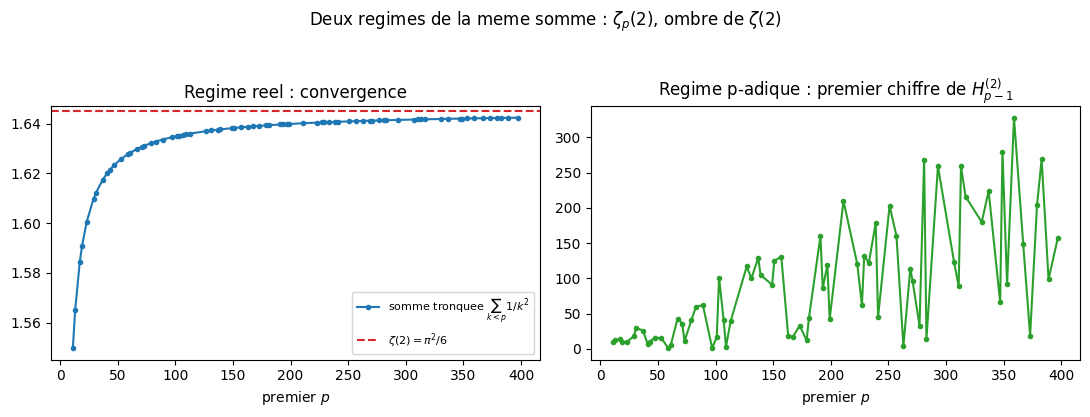

In [8]:
# ============================================================
# Figure : convergence reelle vs oscillation p-adique, cote a cote
# ============================================================
import matplotlib.pyplot as plt

prems_fig = [q for q in premiers(400) if q >= 11]
reel = [sum(1.0 / k ** 2 for k in range(1, p)) for p in prems_fig]
cible = 3.141592653589793 ** 2 / 6
# premier chiffre p-adique de H^(2)_{p-1} : (H mod p^2) // p
ombres = [zeta_p(p, 2, N=2) // p for p in prems_fig]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(prems_fig, reel, "o-", ms=3, label="somme tronquee $\\sum_{k<p} 1/k^2$")
ax1.axhline(cible, color="tab:red", ls="--", label="$\\zeta(2)=\\pi^2/6$")
ax1.set_xlabel("premier $p$")
ax1.set_title("Regime reel : convergence")
ax1.legend(fontsize=8)
ax2.plot(prems_fig, ombres, "o-", ms=3, color="tab:green")
ax2.set_xlabel("premier $p$")
ax2.set_title("Regime p-adique : premier chiffre de $H^{(2)}_{p-1}$")
fig.suptitle("Deux regimes de la meme somme : $\\zeta_p(2)$, ombre de $\\zeta(2)$", y=1.03)
fig.tight_layout()

print(f"Convergence reelle : ecart a pi^2/6 = {abs(reel[-1] - cible):.2e} a p = {prems_fig[-1]}")
print(f"Chiffre p-adique (10 derniers) : {ombres[-10:]}")
print("L'ombre n'a pas de limite quand p varie -- le regime p-adique n'est pas"
      " une approximation du reel : c'est un autre monde, pilote par les Bernoulli.")

plt.show()

In [9]:
# ============================================================
# Le pont de profondeur 2 : zeta_p(1,1) = -(1/3) p B_{p-3} mod p^2
# Derivation : identite de Newton z(1,1) = (H^2 - H^(2)) / 2,
# Wolstenholme tue H^2, le pont de Bernoulli fournit H^(2).
# ============================================================
echecs = 0
tests = 0
for p in [q for q in PRIMES if q >= 11][:10]:
    m2 = p * p
    mesure = zeta_p2(p, 1, 1, N=2)
    attendu = (-inv_mod(3, m2) * p * frac_mod(BER[p - 3], m2)) % m2
    tests += 1
    if mesure != attendu:
        echecs += 1
        print(f"  p={p} : {mesure} != {attendu}")
print(f"PONT prof.2 : zeta_p(1,1) = -(1/3) p B_(p-3) mod p^2 -- "
      f"{tests - echecs}/{tests} premiers exacts")
print()
print("Exemple p = 11 : B_8 =", BER[8], "-> attendu",
      (-inv_mod(3, 121) * 11 * frac_mod(BER[8], 121)) % 121,
      "| mesure", zeta_p2(11, 1, 1, N=2))
print("Et zeta_p(1,1) mod p (couche 1) :", [zeta_p2(p, 1, 1) for p in (11, 13, 17)],
      "-- nul : poids 2 pair, conforme au theoreme de la section 2.")

PONT prof.2 : zeta_p(1,1) = -(1/3) p B_(p-3) mod p^2 -- 10/10 premiers exacts

Exemple p = 11 : B_8 = -1/30 -> attendu 66 | mesure 66
Et zeta_p(1,1) mod p (couche 1) : [0, 0, 0] -- nul : poids 2 pair, conforme au theoreme de la section 2.


### Lecture : la figure, le pont de profondeur 2 — et ce qu'ils disent ensemble

**La figure** montre les deux régimes du *même* symbole : à gauche, la somme tronquée se
colle à $\pi^2/6$ avec l'erreur attendue en $1/p$ ; à droite, le premier chiffre $p$-adique
de la même somme saute de premier en premier sans se stabiliser — et la section 1 a
expliqué chaque saut : ce chiffre est $(2/3)B_{p-3} \bmod p$, un nombre de Bernoulli.
Convergence d'un côté, oscillation bernoullienne de l'autre : l'objet réel et son ombre ne
racontent pas la même histoire, mais les Bernoulli traduisent entre les deux langues.

**Le pont de profondeur 2** boucle la boucle : l'identité de Newton sur
$\big(\sum 1/k\big)^2$ développe $\zeta_p(1,1) = \tfrac{1}{2}\big(H_{p-1}^2 - H^{(2)}_{p-1}\big)$ ;
Wolstenholme annule $H_{p-1}^2$ modulo $p^2$ ; le pont de Bernoulli remplace $H^{(2)}_{p-1}$ ;
il reste

$$\zeta_p(1,1) \;\equiv\; -\tfrac{1}{3}\,p\,B_{p-3} \pmod{p^2}$$

— mesuré exact sur 10 premiers. Une ombre de **profondeur 2** porte donc, en couche 2, la
*même* donnée de Bernoulli que l'ombre de profondeur 1 : l'information ne se duplique pas
par hasard, elle circule par les identités structurelles (Newton, Wolstenholme, Bernoulli).
Et en couche 1, $\zeta_p(1,1) \equiv 0$ : poids $2$ pair, l'effacement dérivé en section 2
s'applique — la mesure le confirme encore.

C'est toute la mécanique de « l'anneau des adèles du pauvre » : peu d'ingrédients (des
inverses modulaires, des Bernoulli exacts, trois identités élémentaires), et déjà les
nombres se répondent à travers les couches et les profondeurs.

## 4. Travaux pratiques

Trois exercices, du plus direct au plus vertigineux. Les squelettes s'exécutent tels quels
(ils n'affirment rien tant qu'ils ne sont pas complétés) ; les `TODO` marquent le travail,
et chaque énoncé est auto-contenu. L'exercice 1 étend le stuffle en profondeur 3,
l'exercice 2 généralise le retournement (et en tire une annulation spectaculaire),
l'exercice 3 part à la chasse au plus célèbre contre-exemple des congruences harmoniques.

In [10]:
# Exercice 1 : profondeur 3 -- implementer zeta_p3 et verifier le stuffle triple
# TODO etudiant
print("Exercice 1 a completer : implementez zeta_p3(m1,m2,m3) puis executez la verification.")

def zeta_p3(p, m1, m2, m3, N=1):
    """Somme 1/(k1^m1 k2^m2 k3^m3) pour 0 < k3 < k2 < k1 < p, dans Z/p^N.
    Indice : imiter zeta_p2 avec une triple boucle ; m1 porte sur la PLUS GRANDE variable."""
    pass  # TODO etudiant : remplacer par la somme
    return None  # TODO etudiant

# Cible (a decommenter) : multiplier zeta_p(2) par zeta_p(2,1) revient a inserer l'indice 2
# dans la chaine (k1 > k2) de cinq facons (i > k1 ; k1 > i > k2 ; i < k2 ; i = k1 ; i = k2),
# d'ou l'identite exacte attendue :
# p = 13
# lhs = (zeta_p(p, 2) * zeta_p2(p, 2, 1)) % p
# rhs = (2 * zeta_p3(p, 2, 2, 1) + zeta_p3(p, 2, 1, 2)  # i>k1 et k1>i>k2 donnent (2,2,1)
#        + zeta_p2(p, 4, 1) + zeta_p2(p, 2, 3)) % p     # i=k1 et i=k2 abaissent la profondeur
# print("stuffle 1x2 :", lhs, rhs, "EGAL" if lhs == rhs else "a verifier")

Exercice 1 a completer : implementez zeta_p3(m1,m2,m3) puis executez la verification.


In [11]:
# Exercice 2 : retournement en profondeur 3, et l'annulation palindrome
# TODO etudiant
print("Exercice 2 a completer : generalisez l'involution (k1,k2,k3) -> (p-k1,p-k2,p-k3),")
print("montrez zeta_p3(m1,m2,m3) = (-1)^w zeta_p3(m3,m2,m1) mod p (w = m1+m2+m3),")
print("puis deduisez-en et verifiez : un indice PALINDROME de poids IMPAIR s'annule.")

# Piste (a decommenter une fois zeta_p3 ecrit a l'exercice 1) :
# for p in (11, 13, 17, 19, 23, 29):
#     assert zeta_p3(p, 3, 1, 2) == zeta_p3(p, 2, 1, 3) % p   # w = 6 pair : egalite
#     assert zeta_p3(p, 2, 1, 2) == 0                          # palindrome, w = 5 impair : nul
# print("retournement prof.3 + palindrome : OK sur 6 premiers")

Exercice 2 a completer : generalisez l'involution (k1,k2,k3) -> (p-k1,p-k2,p-k3),
montrez zeta_p3(m1,m2,m3) = (-1)^w zeta_p3(m3,m2,m1) mod p (w = m1+m2+m3),
puis deduisez-en et verifiez : un indice PALINDROME de poids IMPAIR s'annule.


In [12]:
# Exercice 3 : jusqu'ou va Wolstenholme ? Le nombre premier de Wolstenholme
# TODO etudiant
print("Exercice 3 a completer : zeta_p(1, N=3) pour p = 5, 7, 11, 13, 17 (non nuls :")
print("Wolstenholme s'arrete a p^2), puis testez p = 16843 -- le premier des deux seuls")
print("premiers de Wolstenholme connus, ou H_{p-1} = 0 mod p^3. Somme O(p) : quelques secondes.")

# Piste (a decommenter) :
# for p in (5, 7, 11, 13, 17):
#     print(p, zeta_p(p, 1, N=3))
# print("Wolstenholme prime 16843 : H =", zeta_p(16843, 1, N=3),
#       "-- nul exactement ? (attendu : 0)")

Exercice 3 a completer : zeta_p(1, N=3) pour p = 5, 7, 11, 13, 17 (non nuls :
Wolstenholme s'arrete a p^2), puis testez p = 16843 -- le premier des deux seuls
premiers de Wolstenholme connus, ou H_{p-1} = 0 mod p^3. Somme O(p) : quelques secondes.


## 5. Conclusion et limites honnêtes

**Ce que cette exécution a mesuré** (toutes les identités en arithmétique entière exacte,
aucun flottant dans les congruences) :

| # | Fait | Statut |
|---|---|---|
| 1 | $\zeta_p(s) = 0$ mod $p$ pour $1 \leq s \leq p-2$, et $\zeta_p(p-1) = -1$ | mesuré + preuve (groupe cyclique) |
| 2 | Wolstenholme $H_{p-1} \equiv 0 \pmod{p^2}$ (14 premiers) | mesuré, théorème cité |
| 3 | Leudesdorf $H^{(s)}_{p-1} \equiv 0 \pmod{p^2}$, $s$ impair, $p \geq s+3$ (bord $s{=}3, p{=}5$ non nul) | mesuré, théorème cité |
| 4 | $H^{(2)}_{p-1} \equiv \tfrac{2}{3}pB_{p-3} \pmod{p^2}$ (14 premiers, $B_n$ exacts) | mesuré, théorème cité |
| 5 | Stuffle exact $\zeta_p(m)\zeta_p(n) = \zeta_p(m,n)+\zeta_p(n,m)+\zeta_p(m+n)$ (112 cas) | mesuré + preuve (partition) |
| 6 | Retournement $\zeta_p(m,n) = (-1)^{m+n}\zeta_p(n,m)$ (112 cas) | mesuré + preuve (involution) |
| 7 | Poids pairs de profondeur 2 nuls ($w \leq p-2$) ; poids impairs survivants | dérivé de 1+5+6, mesuré |
| 8 | Transport naïf de la formule d'Euler : vide aux poids pairs, résidu non nul aux poids impairs | mesuré |
| 9 | $\zeta_p(1,1) \equiv -\tfrac{1}{3}pB_{p-3} \pmod{p^2}$ (10 premiers) | dérivé de 2+4+Newton, mesuré |
| 10 | Convergence réelle $\sum_{k<p} k^{-2} \to \pi^2/6$ vs oscillation du chiffre $p$-adique | mesuré (figure) |

**Limites** : une batterie de premiers n'est pas une preuve — les lignes du tableau portent
leur statut, et seules les identités 1, 5, 6 (et la dérivation 7) sont intégralement
prouvées dans la prose, par des arguments élémentaires. Les théorèmes cités (2, 3, 4) sont
vérifiés numériquement seulement. Surtout, le cœur de Kaneko–Zagier — le double shuffle
exact pour la version **symétrique** des ombres, et la conjecture d'isomorphisme avec
l'algèbre des MZV réelles — n'est **pas** établi ici : nous en avons mesuré le motif (le
stuffle passe tel quel) et la nécessité (le shuffle naïf casse). Restent en chantier : les
variantes alternées, la profondeur $\geq 3$ systématique, et la couche $p^3$.

**Suites naturelles** : les exercices (le palindrome de l'exercice 2 est un mini-théorème
à soi tout seul), le notebook 01 de la série (corps finis, borne de Hasse — où les mêmes
Bernoulli comptent des points de courbes), et pour la version formelle, la formalisation
Lean des identités 1, 5, 6 — démontrables à la mesure de ce qu'elles sont : trois lignes
chacune.

*Série Serre100 — distillations exécutables pour le centenaire de Jean-Pierre Serre
(serre100.sciencesconf.org), en son honneur et en sa présence.*